<a href="https://colab.research.google.com/github/NurAyuL27/PCVK_Genap_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2: Import Library**

In [12]:
# Import library yang diperlukan
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Mount Google Drive (jika menggunakan Google Colab)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**3: Histogram Manual**

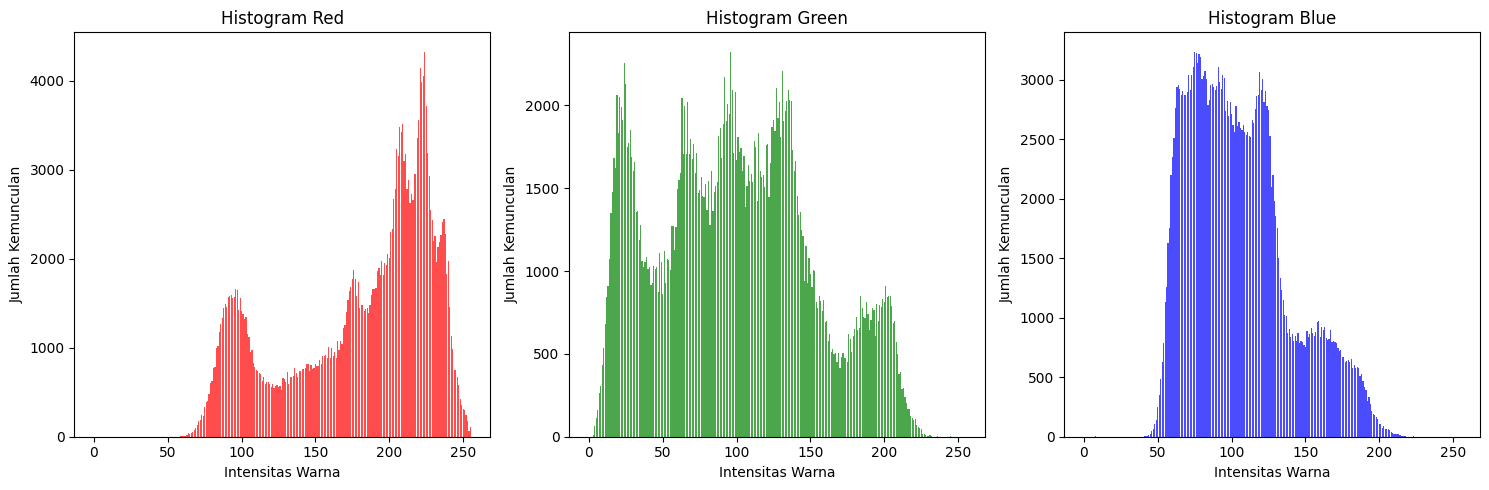

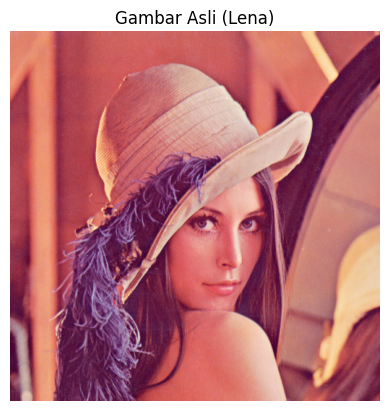

In [14]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.jpg
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# Inisialisasi array untuk menyimpan jumlah kemunculan setiap intensitas (0-255) untuk setiap channel
hist_r = [0] * 256
hist_g = [0] * 256
hist_b = [0] * 256

# Loop melalui setiap pixel
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r, g, b = img_rgb[i, j]
        hist_r[r] += 1
        hist_g[g] += 1
        hist_b[b] += 1

# Plot histogram untuk masing-masing channel R, G, B
plt.figure(figsize=(15, 5))

# Channel Red
plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r, color='red', alpha=0.7)
plt.title('Histogram Red')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Green
plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g, color='green', alpha=0.7)
plt.title('Histogram Green')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Blue
plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b, color='blue', alpha=0.7)
plt.title('Histogram Blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Tampilkan gambar asli
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Gambar Asli (Lena)')
plt.show()


**4: Histogram NumPy**

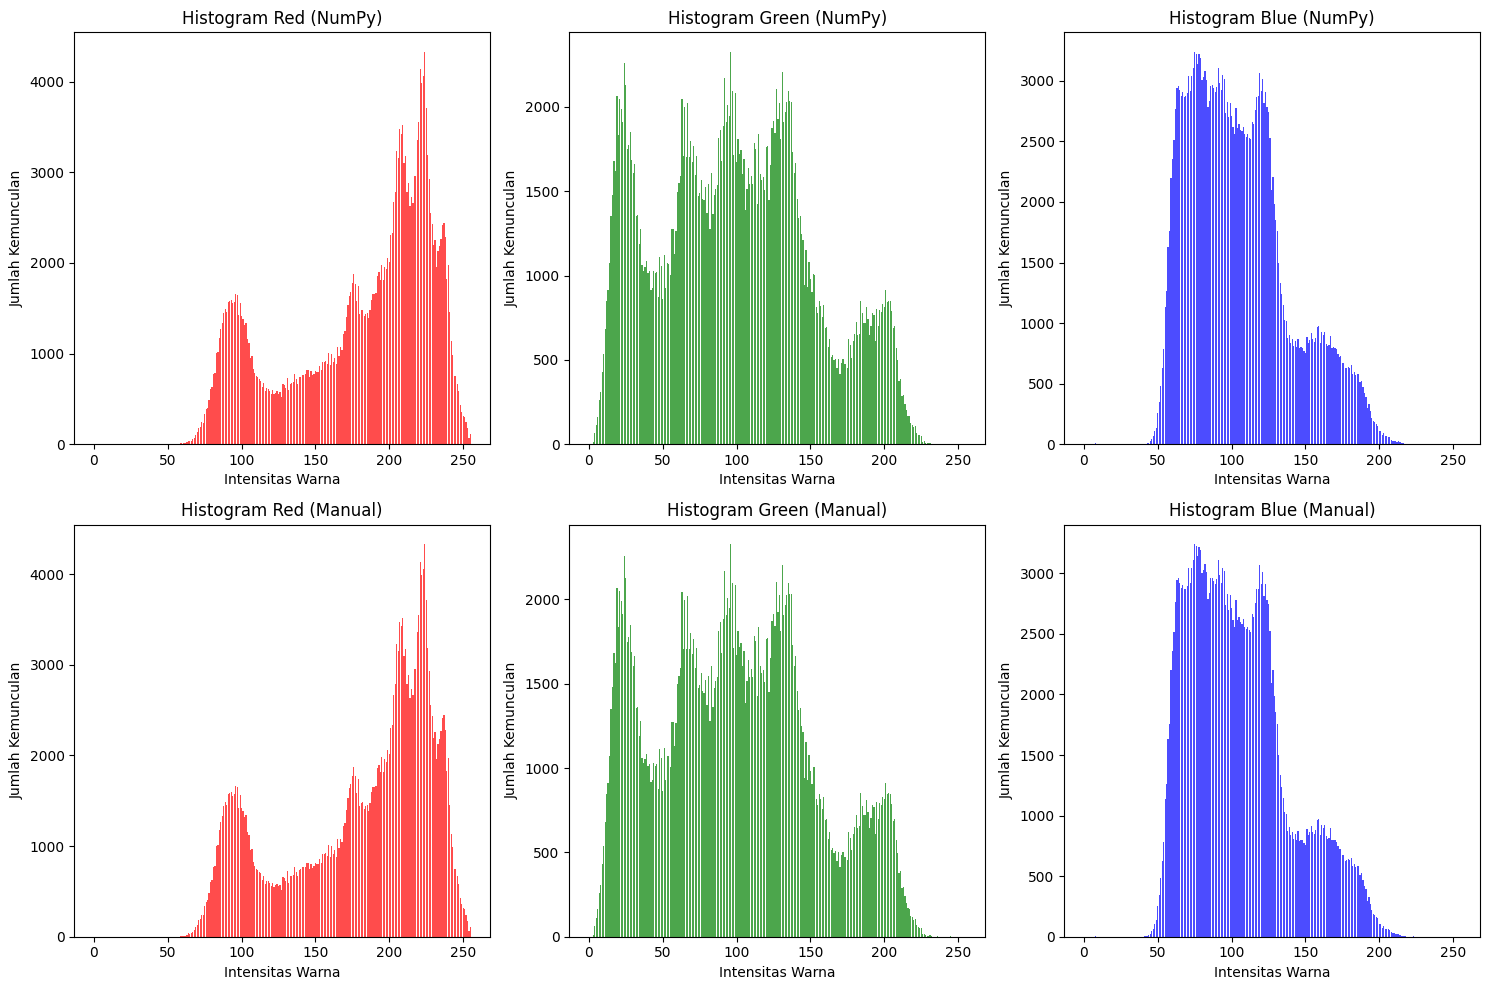


KESIMPULAN: Kedua metode menghasilkan histogram yang IDENTIK!


In [17]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.jpg
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# =============================================
# HISTOGRAM DENGAN NUMPY (Soal yang diminta)
# =============================================

# Menggunakan NumPy's histogram function
hist_r_np, bins_r = np.histogram(img_rgb[:,:,0].flatten(), bins=256, range=[0,256])
hist_g_np, bins_g = np.histogram(img_rgb[:,:,1].flatten(), bins=256, range=[0,256])
hist_b_np, bins_b = np.histogram(img_rgb[:,:,2].flatten(), bins=256, range=[0,256])

# =============================================
# HISTOGRAM MANUAL (Dari kode no. 3)
# =============================================

# Inisialisasi array untuk menyimpan jumlah kemunculan setiap intensitas (0-255) untuk setiap channel
hist_r = [0] * 256
hist_g = [0] * 256
hist_b = [0] * 256

# Loop melalui setiap pixel
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r, g, b = img_rgb[i, j]
        hist_r[r] += 1
        hist_g[g] += 1
        hist_b[b] += 1

# =============================================
# VISUALISASI HISTOGRAM NUMPY
# =============================================

# Plot histogram menggunakan NumPy
plt.figure(figsize=(15, 10))

# Histogram Red (NumPy)
plt.subplot(2, 3, 1)
plt.bar(range(256), hist_r_np, color='red', alpha=0.7)
plt.title('Histogram Red (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Histogram Green (NumPy)
plt.subplot(2, 3, 2)
plt.bar(range(256), hist_g_np, color='green', alpha=0.7)
plt.title('Histogram Green (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Histogram Blue (NumPy)
plt.subplot(2, 3, 3)
plt.bar(range(256), hist_b_np, color='blue', alpha=0.7)
plt.title('Histogram Blue (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Histogram Red (Manual)
plt.subplot(2, 3, 4)
plt.bar(range(256), hist_r, color='red', alpha=0.7)
plt.title('Histogram Red (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Histogram Green (Manual)
plt.subplot(2, 3, 5)
plt.bar(range(256), hist_g, color='green', alpha=0.7)
plt.title('Histogram Green (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Histogram Blue (Manual)
plt.subplot(2, 3, 6)
plt.bar(range(256), hist_b, color='blue', alpha=0.7)
plt.title('Histogram Blue (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# =============================================
# PERBEDAAN ABSOLUT (jika ada)
# =============================================

if not (r_same and g_same and b_same):
    print("\nANALISIS PERBEDAAN:")
    diff_r = np.abs(np.array(hist_r) - hist_r_np)
    diff_g = np.abs(np.array(hist_g) - hist_g_np)
    diff_b = np.abs(np.array(hist_b) - hist_b_np)

    print(f"Perbedaan maksimal pada Red: {np.max(diff_r)}")
    print(f"Perbedaan maksimal pada Green: {np.max(diff_g)}")
    print(f"Perbedaan maksimal pada Blue: {np.max(diff_b)}")

    # Tampilkan gambar asli
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Gambar Asli (Lena)')
    plt.show()
else:
    print("\nKESIMPULAN: Kedua metode menghasilkan histogram yang IDENTIK!")

**5: Histogram Equalization Manual**

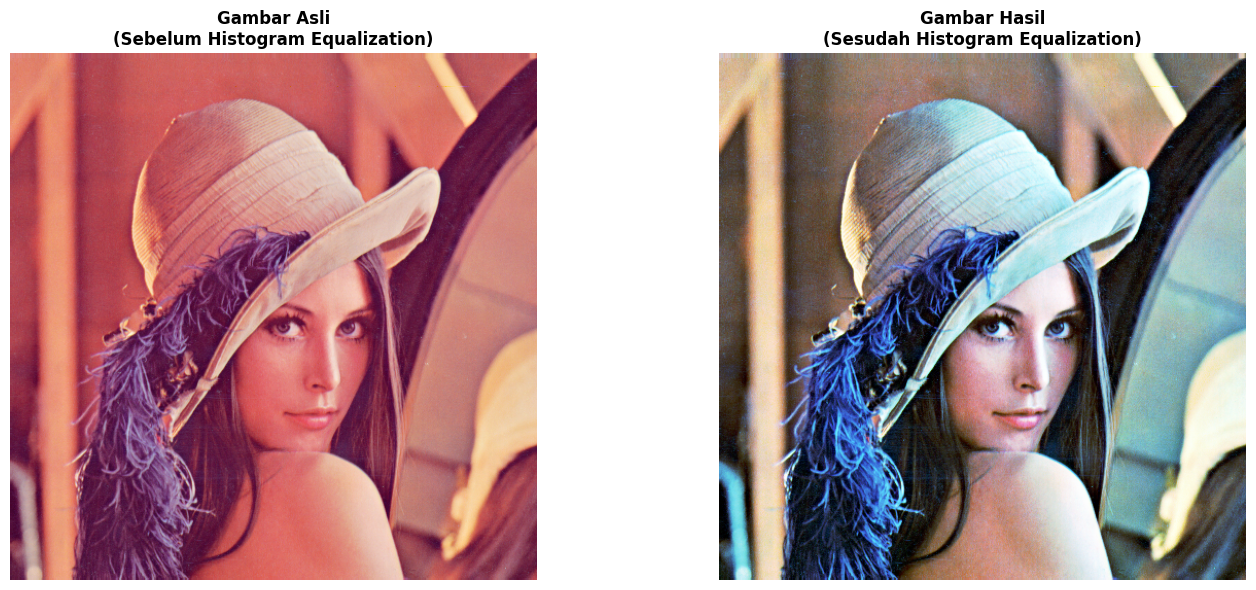

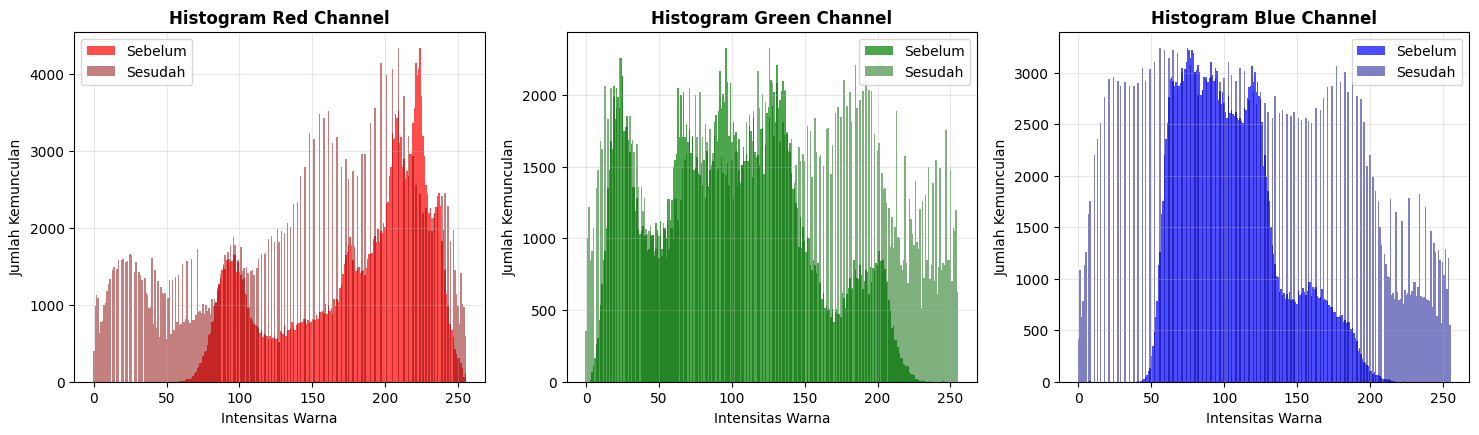

In [26]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.png
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# =============================================
# HISTOGRAM EQUALIZATION BERDASARKAN FLOWCHART
# =============================================

def histogram_equalization_color(img):
    """
    Melakukan histogram equalization pada gambar berwarna
    berdasarkan flowchart yang diberikan
    """
    # Step 1: Input image sudah ada

    # Step 2: Menghitung jumlah kemunculan setiap pixel warna (Frekuensi)
    height, width, channels = img.shape
    total_pixels = height * width

    # Inisialisasi histogram untuk setiap channel
    hist_r = np.zeros(256, dtype=int)
    hist_g = np.zeros(256, dtype=int)
    hist_b = np.zeros(256, dtype=int)

    # Mengisi histogram
    for i in range(height):
        for j in range(width):
            r, g, b = img[i, j]
            hist_r[r] += 1
            hist_g[g] += 1
            hist_b[b] += 1

    # Step 3: Penjumlahan kumulatif dan pembagian dengan jumlah pixel
    cum_r = np.zeros(256)
    cum_g = np.zeros(256)
    cum_b = np.zeros(256)

    cum_r[0] = hist_r[0] / total_pixels
    cum_g[0] = hist_g[0] / total_pixels
    cum_b[0] = hist_b[0] / total_pixels

    for i in range(1, 256):
        cum_r[i] = cum_r[i-1] + (hist_r[i] / total_pixels)
        cum_g[i] = cum_g[i-1] + (hist_g[i] / total_pixels)
        cum_b[i] = cum_b[i-1] + (hist_b[i] / total_pixels)

    # Step 4: Normalisasi dengan kumulatif frekuensi (sudah dilakukan di step 3)

    # Step 5: Implementasi rumus K0 (skala warna)
    # Mengalikan dengan 255 dan membulatkan ke integer
    equalized_r = np.round(cum_r * 255).astype(np.uint8)
    equalized_g = np.round(cum_g * 255).astype(np.uint8)
    equalized_b = np.round(cum_b * 255).astype(np.uint8)

    # Step 6: Hasil Histogram Equalization (dalam bentuk mapping function)

    # Step 7: Transformasi kembali dalam bentuk citra
    img_equalized = np.zeros_like(img)
    for i in range(height):
        for j in range(width):
            r, g, b = img[i, j]
            img_equalized[i, j, 0] = equalized_r[r]
            img_equalized[i, j, 1] = equalized_g[g]
            img_equalized[i, j, 2] = equalized_b[b]

    # Step 8: Citra Hasil Histogram Equalization
    return img_equalized, hist_r, hist_g, hist_b, equalized_r, equalized_g, equalized_b

# Melakukan histogram equalization
img_equalized, hist_r, hist_g, hist_b, eq_r, eq_g, eq_b = histogram_equalization_color(img_rgb)

# Menghitung histogram untuk gambar setelah equalization
hist_r_eq = np.zeros(256, dtype=int)
hist_g_eq = np.zeros(256, dtype=int)
hist_b_eq = np.zeros(256, dtype=int)

height, width = img_equalized.shape[:2]
for i in range(height):
    for j in range(width):
        r, g, b = img_equalized[i, j]
        hist_r_eq[r] += 1
        hist_g_eq[g] += 1
        hist_b_eq[b] += 1

# =============================================
# VISUALISASI HASIL - DIPERBAIKI DAN DIRAPIKAN
# =============================================

# Plot 1: Perbandingan Gambar Sebelum dan Sesudah
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli\n(Sebelum Histogram Equalization)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equalized)
plt.title('Gambar Hasil\n(Sesudah Histogram Equalization)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

# Plot 2: Histogram Comparison
plt.figure(figsize=(18, 10))

# Histogram Red sebelum dan sesudah
plt.subplot(2, 3, 1)
plt.bar(range(256), hist_r, color='red', alpha=0.7, label='Sebelum', width=1.0)
plt.bar(range(256), hist_r_eq, color='darkred', alpha=0.5, label='Sesudah', width=1.0)
plt.title('Histogram Red Channel', fontsize=12, fontweight='bold')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram Green sebelum dan sesudah
plt.subplot(2, 3, 2)
plt.bar(range(256), hist_g, color='green', alpha=0.7, label='Sebelum', width=1.0)
plt.bar(range(256), hist_g_eq, color='darkgreen', alpha=0.5, label='Sesudah', width=1.0)
plt.title('Histogram Green Channel', fontsize=12, fontweight='bold')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram Blue sebelum dan sesudah
plt.subplot(2, 3, 3)
plt.bar(range(256), hist_b, color='blue', alpha=0.7, label='Sebelum', width=1.0)
plt.bar(range(256), hist_b_eq, color='darkblue', alpha=0.5, label='Sesudah', width=1.0)
plt.title('Histogram Blue Channel', fontsize=12, fontweight='bold')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.grid(True, alpha=0.3)


**6: Histogram Equalization CV2**

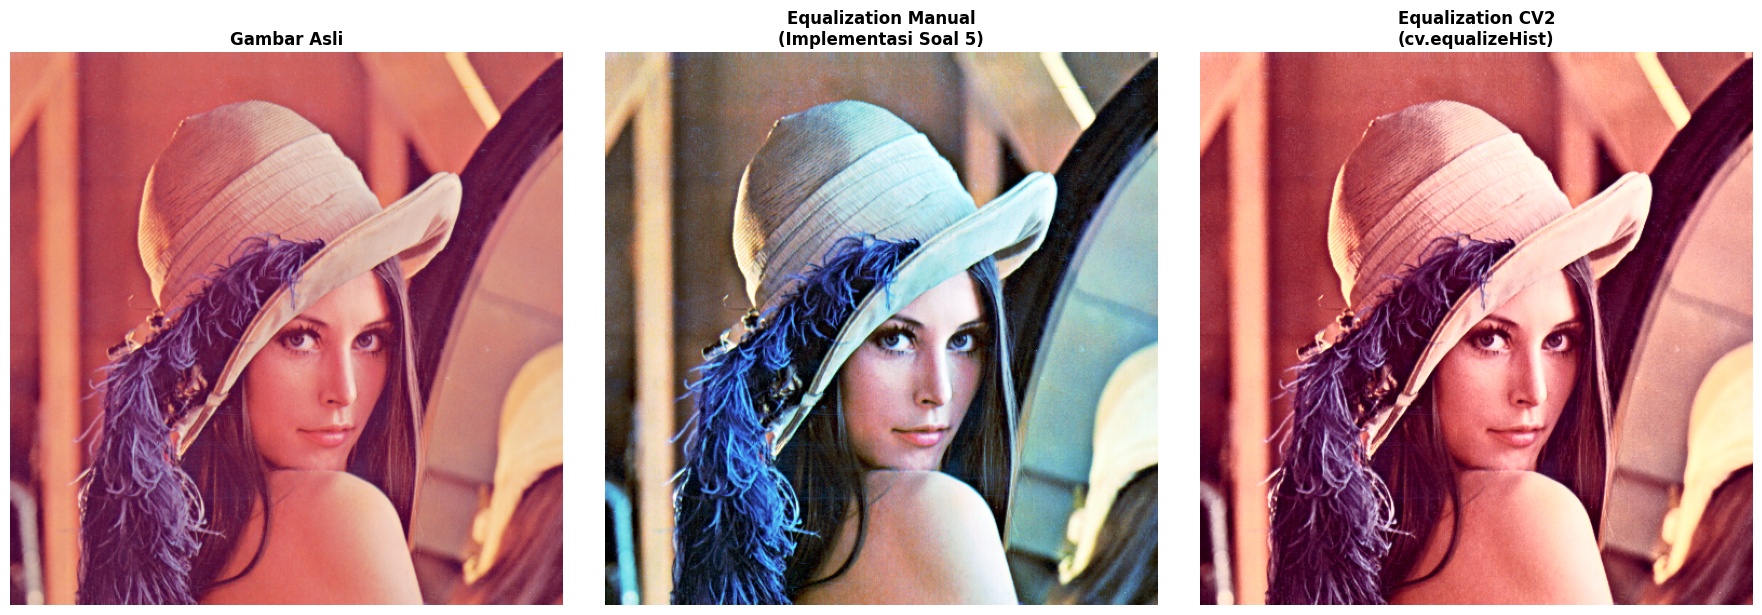

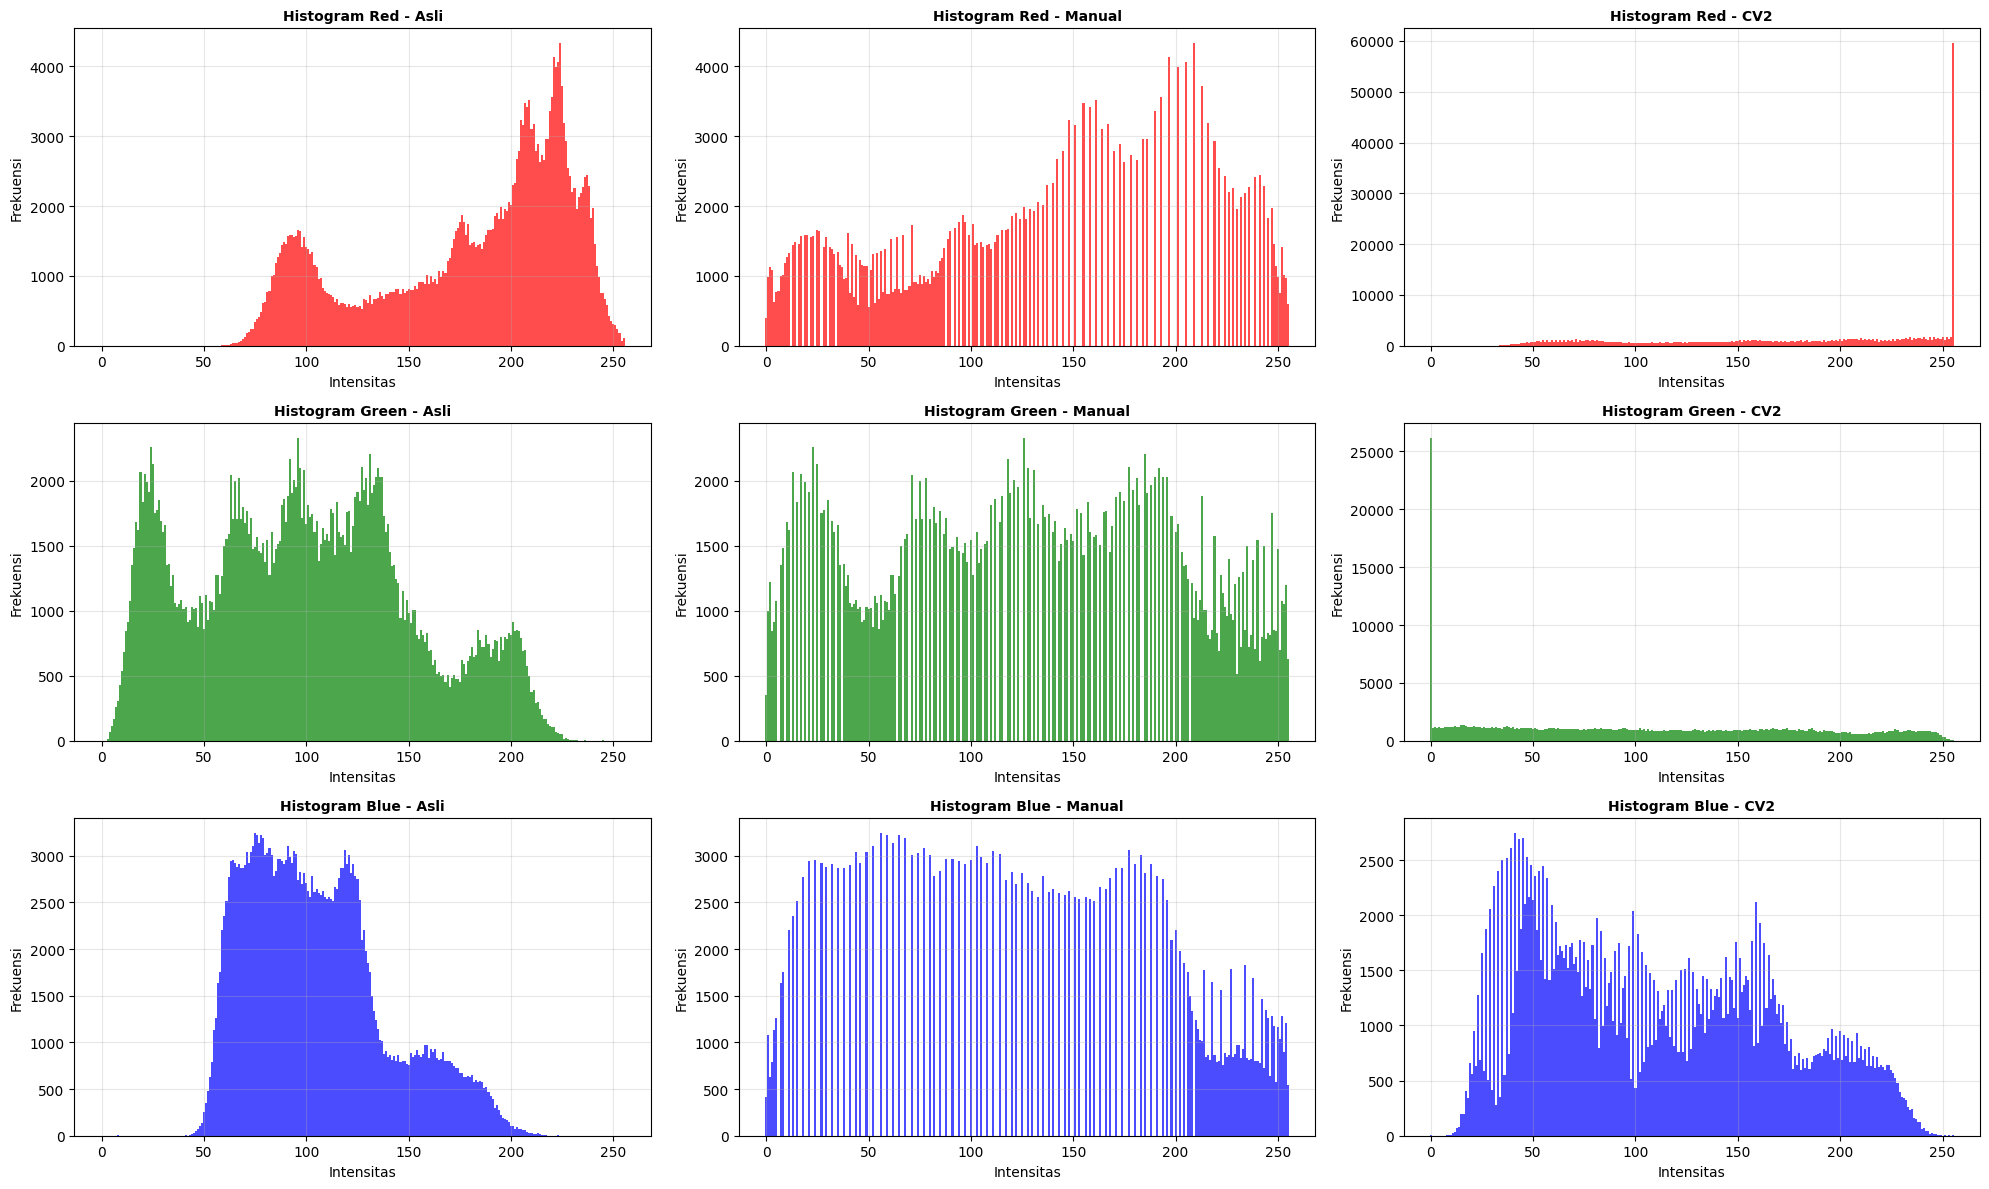


KESIMPULAN:
✗ Output kedua metode BERBEDA
  Terdapat perbedaan yang signifikan antara kedua metode


In [28]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.png
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# =============================================
# HISTOGRAM EQUALIZATION BERDASARKAN FLOWCHART (DARI SOAL 5)
# =============================================

def histogram_equalization_color(img):
    """
    Melakukan histogram equalization pada gambar berwarna
    berdasarkan flowchart yang diberikan
    """
    # Step 1: Input image sudah ada

    # Step 2: Menghitung jumlah kemunculan setiap pixel warna (Frekuensi)
    height, width, channels = img.shape
    total_pixels = height * width

    # Inisialisasi histogram untuk setiap channel
    hist_r = np.zeros(256, dtype=int)
    hist_g = np.zeros(256, dtype=int)
    hist_b = np.zeros(256, dtype=int)

    # Mengisi histogram
    for i in range(height):
        for j in range(width):
            r, g, b = img[i, j]
            hist_r[r] += 1
            hist_g[g] += 1
            hist_b[b] += 1

    # Step 3: Penjumlahan kumulatif dan pembagian dengan jumlah pixel
    cum_r = np.zeros(256)
    cum_g = np.zeros(256)
    cum_b = np.zeros(256)

    cum_r[0] = hist_r[0] / total_pixels
    cum_g[0] = hist_g[0] / total_pixels
    cum_b[0] = hist_b[0] / total_pixels

    for i in range(1, 256):
        cum_r[i] = cum_r[i-1] + (hist_r[i] / total_pixels)
        cum_g[i] = cum_g[i-1] + (hist_g[i] / total_pixels)
        cum_b[i] = cum_b[i-1] + (hist_b[i] / total_pixels)

    # Step 4: Normalisasi dengan kumulatif frekuensi (sudah dilakukan di step 3)

    # Step 5: Implementasi rumus K0 (skala warna)
    # Mengalikan dengan 255 dan membulatkan ke integer
    equalized_r = np.round(cum_r * 255).astype(np.uint8)
    equalized_g = np.round(cum_g * 255).astype(np.uint8)
    equalized_b = np.round(cum_b * 255).astype(np.uint8)

    # Step 6: Hasil Histogram Equalization (dalam bentuk mapping function)

    # Step 7: Transformasi kembali dalam bentuk citra
    img_equalized = np.zeros_like(img)
    for i in range(height):
        for j in range(width):
            r, g, b = img[i, j]
            img_equalized[i, j, 0] = equalized_r[r]
            img_equalized[i, j, 1] = equalized_g[g]
            img_equalized[i, j, 2] = equalized_b[b]

    # Step 8: Citra Hasil Histogram Equalization
    return img_equalized, hist_r, hist_g, hist_b, equalized_r, equalized_g, equalized_b

# =============================================
# HISTOGRAM EQUALIZATION MENGGUNAKAN CV2
# =============================================

def histogram_equalization_cv2(img):
    """
    Melakukan histogram equalization menggunakan fungsi built-in CV2
    """
    # Konversi ke YUV color space untuk equalization yang lebih baik
    img_yuv = cv.cvtColor(img, cv.COLOR_RGB2YUV)

    # Equalize histogram pada channel Y (luminance)
    img_yuv[:,:,0] = cv.equalizeHist(img_yuv[:,:,0])

    # Konversi kembali ke RGB
    img_equalized_cv2 = cv.cvtColor(img_yuv, cv.COLOR_YUV2RGB)

    return img_equalized_cv2

# =============================================
# PROSES EQUALIZATION DENGAN DUA METODE
# =============================================

# Metode manual (dari soal 5)
img_equalized_manual, hist_r, hist_g, hist_b, eq_r, eq_g, eq_b = histogram_equalization_color(img_rgb)

# Metode CV2
img_equalized_cv2 = histogram_equalization_cv2(img_rgb)

# =============================================
# MENGHITUNG HISTOGRAM UNTUK SEMUA GAMBAR
# =============================================

def calculate_histogram(img):
    """Menghitung histogram untuk gambar RGB"""
    hist_r = np.zeros(256, dtype=int)
    hist_g = np.zeros(256, dtype=int)
    hist_b = np.zeros(256, dtype=int)

    height, width = img.shape[:2]
    for i in range(height):
        for j in range(width):
            r, g, b = img[i, j]
            hist_r[r] += 1
            hist_g[g] += 1
            hist_b[b] += 1

    return hist_r, hist_g, hist_b

# Histogram untuk gambar asli
hist_r_orig, hist_g_orig, hist_b_orig = calculate_histogram(img_rgb)

# Histogram untuk gambar manual equalization
hist_r_manual, hist_g_manual, hist_b_manual = calculate_histogram(img_equalized_manual)

# Histogram untuk gambar CV2 equalization
hist_r_cv2, hist_g_cv2, hist_b_cv2 = calculate_histogram(img_equalized_cv2)

# =============================================
# VISUALISASI PERBANDINGAN
# =============================================

# Plot 1: Perbandingan Gambar
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Gambar Asli', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_equalized_manual)
plt.title('Equalization Manual\n(Implementasi Soal 5)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_equalized_cv2)
plt.title('Equalization CV2\n(cv.equalizeHist)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

# Plot 2: Perbandingan Histogram
plt.figure(figsize=(20, 12))

# Histogram Red Channel
plt.subplot(3, 3, 1)
plt.bar(range(256), hist_r_orig, color='red', alpha=0.7, label='Asli', width=1.0)
plt.title('Histogram Red - Asli', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 2)
plt.bar(range(256), hist_r_manual, color='red', alpha=0.7, label='Manual', width=1.0)
plt.title('Histogram Red - Manual', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 3)
plt.bar(range(256), hist_r_cv2, color='red', alpha=0.7, label='CV2', width=1.0)
plt.title('Histogram Red - CV2', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

# Histogram Green Channel
plt.subplot(3, 3, 4)
plt.bar(range(256), hist_g_orig, color='green', alpha=0.7, label='Asli', width=1.0)
plt.title('Histogram Green - Asli', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.bar(range(256), hist_g_manual, color='green', alpha=0.7, label='Manual', width=1.0)
plt.title('Histogram Green - Manual', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.bar(range(256), hist_g_cv2, color='green', alpha=0.7, label='CV2', width=1.0)
plt.title('Histogram Green - CV2', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

# Histogram Blue Channel
plt.subplot(3, 3, 7)
plt.bar(range(256), hist_b_orig, color='blue', alpha=0.7, label='Asli', width=1.0)
plt.title('Histogram Blue - Asli', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 8)
plt.bar(range(256), hist_b_manual, color='blue', alpha=0.7, label='Manual', width=1.0)
plt.title('Histogram Blue - Manual', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 9)
plt.bar(range(256), hist_b_cv2, color='blue', alpha=0.7, label='CV2', width=1.0)
plt.title('Histogram Blue - CV2', fontsize=10, fontweight='bold')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# ANALISIS PERBANDINGAN
# =============================================

print("\nKESIMPULAN:")
if mse < 1.0 and mean_difference < 1.0:
    print("✓ Output kedua metode MIRIP/SAMA")
    print("  Perbedaan sangat kecil dan tidak signifikan secara visual")
else:
    print("✗ Output kedua metode BERBEDA")
    print("  Terdapat perbedaan yang signifikan antara kedua metode")

**7: Pemetaan ke 8 Warna**

Memproses pemetaan 16 juta warna ke 8 warna...


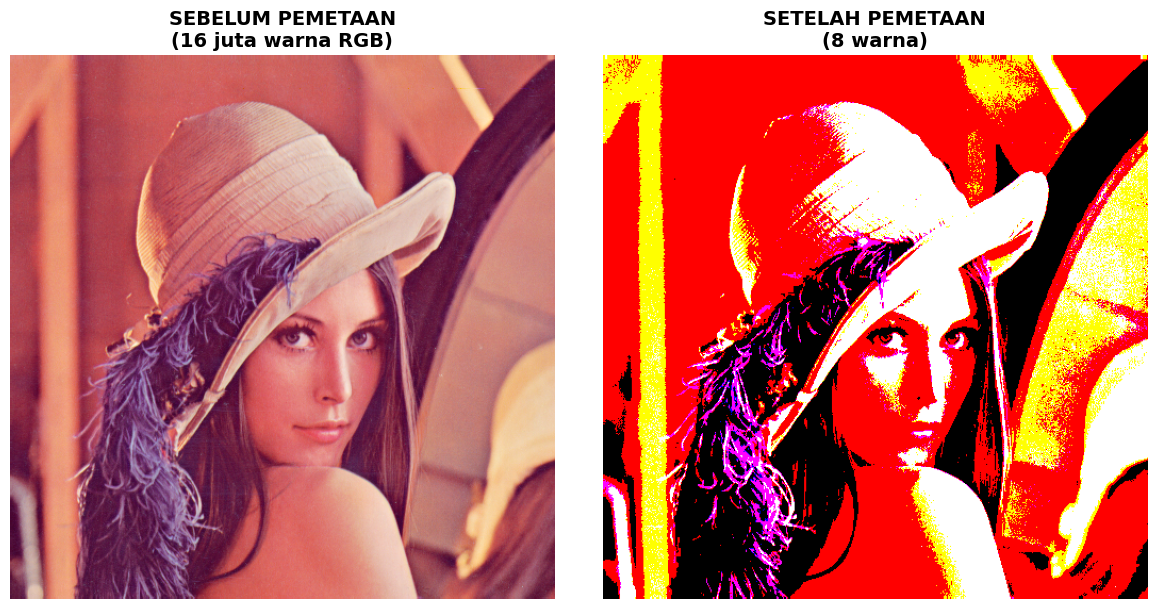

In [31]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.png
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# =============================================
# DEFINISI 8 WARNA TARGET
# =============================================
colors_8 = {
    'hitam':    [0, 0, 0],      # Black
    'merah':    [255, 0, 0],    # Red
    'hijau':    [0, 255, 0],    # Green
    'kuning':   [255, 255, 0],  # Yellow
    'biru':     [0, 0, 255],    # Blue
    'magenta':  [255, 0, 255],  # Magenta
    'cyan':     [0, 255, 255],  # Cyan
    'putih':    [255, 255, 255] # White
}

# Konversi ke numpy array
color_values = np.array(list(colors_8.values()), dtype=np.uint8)

# =============================================
# FUNGSI PEMETAAN WARNA BERDASARKAN FLOWCHART
# =============================================

def map_to_8_colors(img):
    """
    Memetakan 16 juta warna RGB ke 8 warna menggunakan metode threshold
    berdasarkan flowchart
    """
    height, width, channels = img.shape
    img_mapped = np.zeros_like(img)

    for i in range(height):
        for j in range(width):
            r, g, b = img[i, j]

            # Threshold pada 128 (nilai tengah range 0-255)
            r_thresh = 1 if r >= 128 else 0
            g_thresh = 1 if g >= 128 else 0
            b_thresh = 1 if b >= 128 else 0

            # Mapping ke indeks berdasarkan kombinasi threshold
            # Format: [R, G, B] sebagai binary
            color_index = (r_thresh << 2) | (g_thresh << 1) | b_thresh

            # Mapping index ke warna
            color_mapping = {
                0: 0,  # 000 -> hitam
                1: 4,  # 001 -> biru
                2: 2,  # 010 -> hijau
                3: 6,  # 011 -> cyan
                4: 1,  # 100 -> merah
                5: 5,  # 101 -> magenta
                6: 3,  # 110 -> kuning
                7: 7   # 111 -> putih
            }
            closest_idx = color_mapping[color_index]

            # Assign warna terdekat
            img_mapped[i, j] = color_values[closest_idx]

    return img_mapped

# =============================================
# PROSES PEMETAAN
# =============================================

print("Memproses pemetaan 16 juta warna ke 8 warna...")
img_8_colors = map_to_8_colors(img_rgb)

# =============================================
# VISUALISASI HASIL (HANYA 2 GAMBAR)
# =============================================

plt.figure(figsize=(12, 6))

# Gambar asli - SEBELUM PEMETAAN
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('SEBELUM PEMETAAN\n(16 juta warna RGB)', fontsize=14, fontweight='bold')
plt.axis('off')

# Gambar hasil - SETELAH PEMETAAN
plt.subplot(1, 2, 2)
plt.imshow(img_8_colors)
plt.title('SETELAH PEMETAAN\n(8 warna)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

**8: Dithering Floyd-Steinberg**

Melakukan proses dithering Floyd-Steinberg...


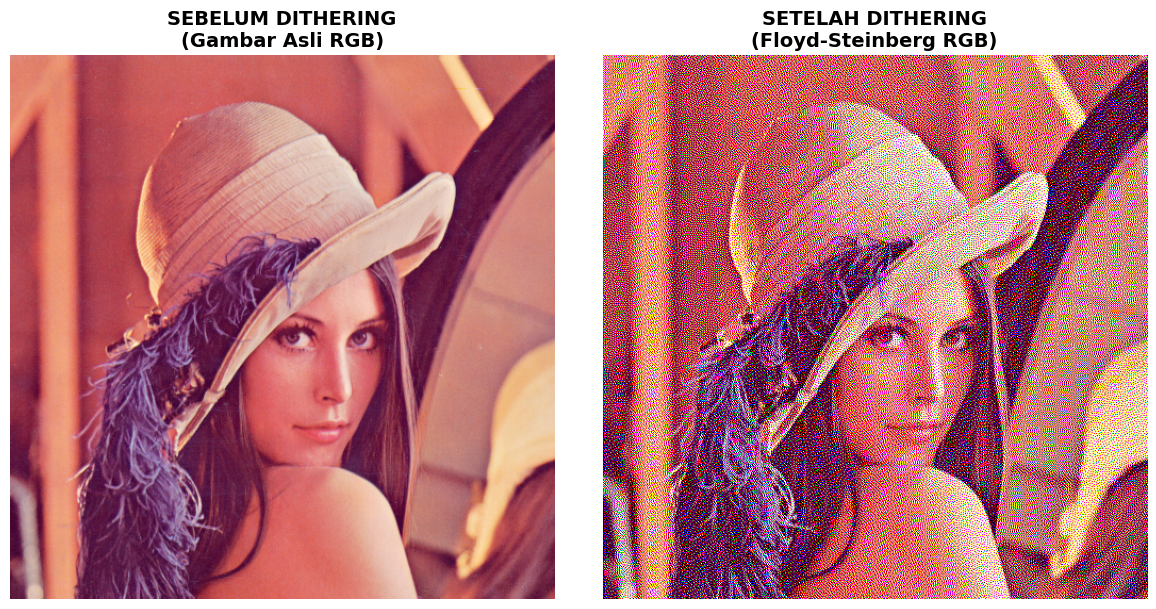

In [34]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.png
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# =============================================
# FUNGSI DITHERING FLOYD-STEINBERG UNTUK RGB
# =============================================

def floyd_steinberg_dithering_rgb(img):
    """
    Melakukan dithering Floyd-Steinberg pada gambar RGB
    """
    # Copy gambar untuk diolah
    img_dithered = img.copy().astype(np.float32)
    height, width, channels = img_dithered.shape

    # Loop melalui setiap pixel
    for y in range(height):
        for x in range(width):
            # Simpan nilai pixel lama
            old_pixel = img_dithered[y, x].copy()

            # Quantize ke 0 atau 255 untuk setiap channel
            new_pixel = np.where(old_pixel >= 128, 255, 0)

            # Set pixel baru
            img_dithered[y, x] = new_pixel

            # Hitung error untuk setiap channel
            quant_error = old_pixel - new_pixel

            # Sebarkan error ke pixel tetangga (Floyd-Steinberg)
            if x + 1 < width:
                img_dithered[y, x + 1] += quant_error * 7/16

            if y + 1 < height:
                if x - 1 >= 0:
                    img_dithered[y + 1, x - 1] += quant_error * 3/16

                img_dithered[y + 1, x] += quant_error * 5/16

                if x + 1 < width:
                    img_dithered[y + 1, x + 1] += quant_error * 1/16

    # Konversi kembali ke uint8
    img_dithered = np.clip(img_dithered, 0, 255).astype(np.uint8)
    return img_dithered

# =============================================
# PROSES DITHERING
# =============================================

print("Melakukan proses dithering Floyd-Steinberg...")
img_dithered = floyd_steinberg_dithering_rgb(img_rgb)

# =============================================
# VISUALISASI HASIL (HANYA 2 GAMBAR)
# =============================================

plt.figure(figsize=(12, 6))

# Gambar asli - SEBELUM DITHERING
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('SEBELUM DITHERING\n(Gambar Asli RGB)', fontsize=14, fontweight='bold')
plt.axis('off')

# Gambar hasil - SETELAH DITHERING
plt.subplot(1, 2, 2)
plt.imshow(img_dithered)
plt.title('SETELAH DITHERING\n(Floyd-Steinberg RGB)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

**9: Kombinasi HE + Dithering**

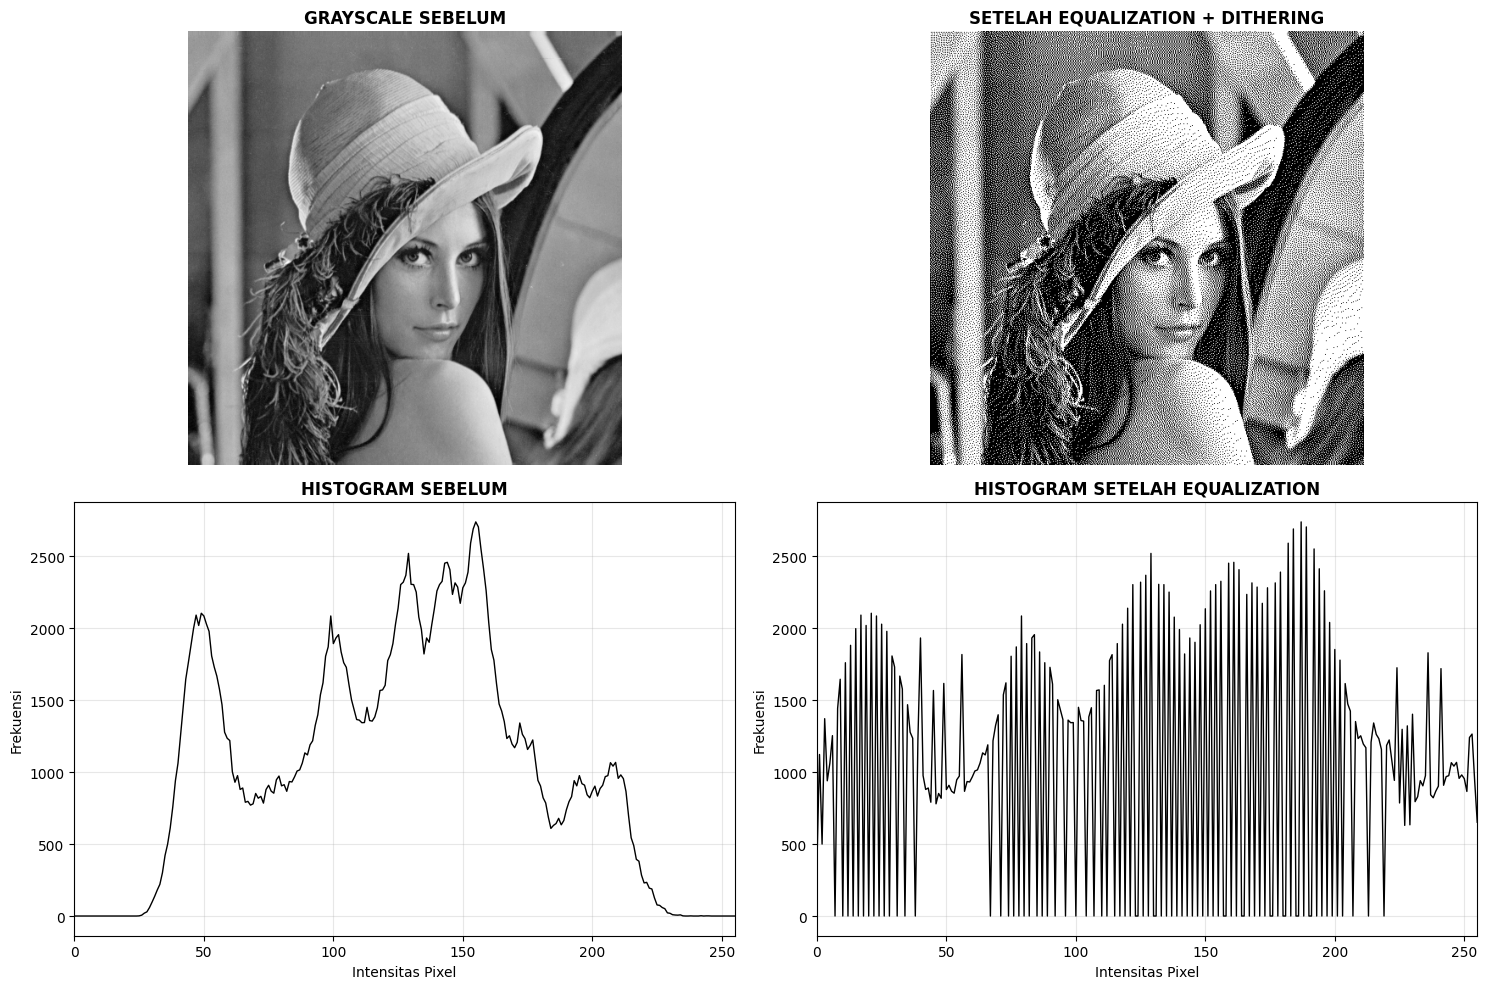

In [36]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.png
img = cv.imread('/content/drive/MyDrive/lena.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# =============================================
# KONVERSI KE GRAYSCALE
# =============================================
img_gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)

# =============================================
# HISTOGRAM EQUALIZATION
# =============================================
img_equalized = cv.equalizeHist(img_gray)

# =============================================
# FUNGSI DITHERING FLOYD-STEINBERG UNTUK GRAYSCALE
# =============================================
def floyd_steinberg_dithering_grayscale(img):
    """
    Melakukan dithering Floyd-Steinberg pada gambar grayscale
    """
    img_dithered = img.copy().astype(np.float32)
    height, width = img_dithered.shape

    for y in range(height):
        for x in range(width):
            old_pixel = img_dithered[y, x]
            new_pixel = 255 if old_pixel >= 128 else 0
            img_dithered[y, x] = new_pixel

            quant_error = old_pixel - new_pixel

            # Sebarkan error ke pixel tetangga
            if x + 1 < width:
                img_dithered[y, x + 1] += quant_error * 7/16

            if y + 1 < height:
                if x - 1 >= 0:
                    img_dithered[y + 1, x - 1] += quant_error * 3/16

                img_dithered[y + 1, x] += quant_error * 5/16

                if x + 1 < width:
                    img_dithered[y + 1, x + 1] += quant_error * 1/16

    return np.clip(img_dithered, 0, 255).astype(np.uint8)

# =============================================
# PROSES DITHERING PADA HASIL EQUALIZATION
# =============================================
img_dithered = floyd_steinberg_dithering_grayscale(img_equalized)

# =============================================
# VISUALISASI HASIL - 2 BARIS, 2 KOLOM
# =============================================
plt.figure(figsize=(15, 10))

# BARIS 1: Gambar sebelum dan sesudah
# Gambar grayscale asli
plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('GRAYSCALE SEBELUM', fontsize=12, fontweight='bold')
plt.axis('off')

# Gambar setelah equalization + dithering
plt.subplot(2, 2, 2)
plt.imshow(img_dithered, cmap='gray')
plt.title('SETELAH EQUALIZATION + DITHERING', fontsize=12, fontweight='bold')
plt.axis('off')

# BARIS 2: Histogram sebelum dan sesudah
# Histogram grayscale asli
plt.subplot(2, 2, 3)
hist_before = cv.calcHist([img_gray], [0], None, [256], [0, 256])
plt.plot(hist_before, color='black', linewidth=1)
plt.title('HISTOGRAM SEBELUM', fontsize=12, fontweight='bold')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.xlim([0, 255])

# Histogram setelah equalization
plt.subplot(2, 2, 4)
hist_after = cv.calcHist([img_equalized], [0], None, [256], [0, 256])
plt.plot(hist_after, color='black', linewidth=1)
plt.title('HISTOGRAM SETELAH EQUALIZATION', fontsize=12, fontweight='bold')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.xlim([0, 255])

plt.tight_layout()
plt.show()